In [1]:
!pip install --user torch torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [2]:
!pip install --user opencv-python py-cpuinfo ultralytics-thop

In [3]:
!pip install ultralytics --no-deps --no-cache-dir --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 10.7 MB/s eta 0:00:00 0:00:01
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.154
    Uninstalling ultralytics-8.3.154:
      Successfully uninstalled ultralytics-8.3.154


In [6]:
!pip install --user opencv-python-headless --force-reinstall --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 99.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 99.7 MB/s eta 0:00:00ta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.14.1 requires numpy<2.3,>=1.23.5, but you have numpy 2.3.0 which is incompatible.


In [7]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/jovyan/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
# Descarga automática de yolov8n si no está en el directorio
model = YOLO('yolov8n.pt')  # también puedes usar 'yolov8n-seg.pt' para segmentación

100%|██████████| 6.25M/6.25M [00:00<00:00, 29.1MB/s]


In [9]:
# 📸 Paso 3: Cargar imagen desde carpeta 'imagenes'
import cv2
import matplotlib.pyplot as plt

In [22]:
# Cambia esto por el nombre de tu imagen
ruta_imagen = "imagenes/snapshot03.png"

In [23]:
# Leer imagen con OpenCV (BGR)
imagen = cv2.imread(ruta_imagen)
if imagen is None:
    raise FileNotFoundError(f"No se encontró la imagen en: {ruta_imagen}")

In [24]:
# Convertir a RGB para mostrar con matplotlib
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

In [25]:
# 🔍 Paso 4: Ejecutar inferencia
resultados = model(imagen)


0: 288x640 2 kites, 20.6ms
Speed: 2.8ms preprocess, 20.6ms inference, 0.7ms postprocess per image at shape (1, 3, 288, 640)


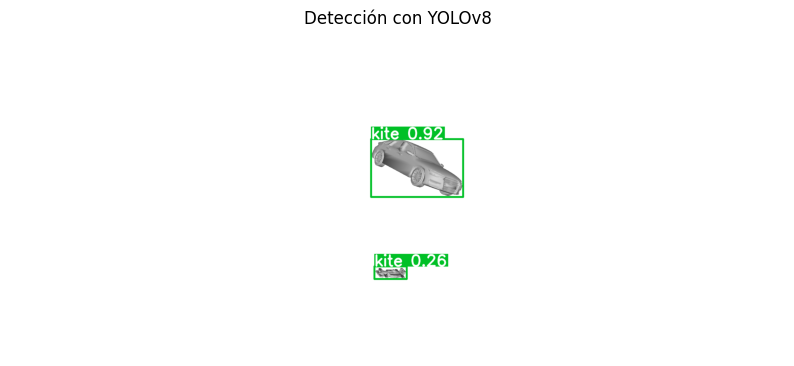

In [26]:
# 🖼️ Paso 5: Mostrar imagen con anotaciones
# results[0].plot() retorna un arreglo numpy con la imagen anotada
imagen_anotada = resultados[0].plot()

plt.figure(figsize=(10, 8))
plt.imshow(imagen_anotada)
plt.axis('off')
plt.title("Detección con YOLOv8")
plt.show()